### R6 - NeuralNetwork and Deep Learning : Project 1

The case study is from an open source dataset from Kaggle. 

Link to the Kaggle project site:

https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling (Links to an external site.)Links to an external site.

 

Given a Bank customer, can we build a classifier which can determine whether they will leave or not using Neural networks?

The points distribution for this case is as follows:

1. Read the dataset
2. Drop the columns which are unique for all users like IDs (5 points)
3. Distinguish the feature and target set (5 points)
4. Divide the data set into Train and test sets
5. Normalize the train and test data (5 points)
6. Initialize & build the model (10 points)
7. Optimize the model (Optional)
8. Predict the results using 0.5 as a threshold (Optional)
9. Print the Accuracy score and confusion matrix (5 points)

In [1]:
# import numpy and pandas library
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
# calculate accuracy measures and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

In [3]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [4]:
import warnings 
warnings.filterwarnings('ignore')

### Questions :

### 1. Read the dataset

In [43]:
#Read bank data from csv file
bank_df = pd.read_csv("bank.csv")

In [44]:
bank_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [45]:
bank_df.shape

(10000, 14)

In [46]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
#Check Missing value if any
bank_df.isnull().values.any()

False

### Data Obervation:

1. In the given Baning dataset we have around 10,000 Rows and 14 Columns.
2. As per problem statement, Model Predictor (Y) field is "Exited".
3. Geography and Gender column is Categorical Type
4. There is no missing value in the dataset
5. "CustomerId","Surname" and "RowNumber" are not ruquired for modeling and hence we can drop this column

### 2. Drop the columns which are unique for all users like IDs (5 points)

In [47]:
#Drop "RowNumber","CustomerId","Surname" column which are not required for modeling.
bank_df = bank_df.drop(["RowNumber","CustomerId","Surname"], axis = 1)

In [48]:
bank_df.shape

(10000, 11)

### 3. Distinguish the feature and target set (5 points)

In [12]:
bank_df["Exited"].value_counts()

0    7963
1    2037
Name: Exited, dtype: int64

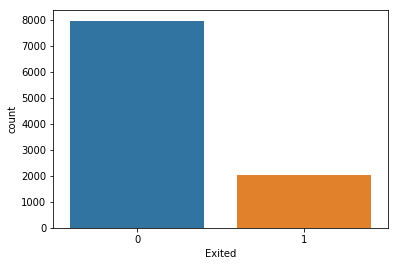

In [13]:
plot = sns.countplot(x = "Exited", data = bank_df)
plot.set_xticklabels(plot.get_xticklabels());

In [14]:
bank_df["Geography"].value_counts()

France     5014
Germany    2509
Spain      2477
Name: Geography, dtype: int64

In [15]:
bank_df["Gender"].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [16]:
#Since "Geography" and "Gender" are categorical column lets do get_dummies and drop first. 
bank_df = pd.get_dummies(bank_df,drop_first=True)

In [17]:
bank_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [18]:
bank_df.shape

(10000, 12)

### Feature And Target Column Observation:

1. In the given dataset we have 2037 customers are "Exited" (1) and 7963 are "Not-Exited" (0). Looks its imbalanced dataset. Since we have just 23% of "Exited"customer list. 
2. It would be better if we do boots-strap sampling to increase "Exited" datarows before we do the modelling. Which help us to get better accuracy.
2. Since "Geography" and "Gender" are categorical column, we have done get dummies and dropped first one.
3. Finnaly,in our dataset we have 12 Column which we going to use for modeling.

### 4. Divide the data set into Train and test sets

In [19]:
# Get independent variable in X
X = bank_df.drop(["Exited"], axis=1)
# Get Target variable in y
y = bank_df["Exited"]

In [20]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [21]:
print("Bank Train Data Shape : {0}".format(X_train.shape))
print("Bank Test Data Shape : {0}".format(X_test.shape))
print("Bank Full Data Shape : {0}".format(X.shape))

Bank Train Data Shape : (7000, 11)
Bank Test Data Shape : (3000, 11)
Bank Full Data Shape : (10000, 11)


### 5. Normalize the train and test data (5 points)

In [22]:
# For NN model it's alway good if we do data normalization
from sklearn.preprocessing import StandardScaler

transformer = StandardScaler()
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

### 6. Initialize & build the model (10 points)

In [23]:
#Import Tensorflow & Keras Library
import tensorflow as tf
import keras

Using TensorFlow backend.


In [49]:
#Initialize Sequential model
model = tf.keras.models.Sequential()
#Add Dense Layer to create a hidden layer of 6 neurons with Relu activation
model.add(tf.keras.layers.Dense(6,  activation='relu', input_shape=(11,)))
#Add Dense Layer to create a hidden layer of 6 neurons with Relu activation
model.add(tf.keras.layers.Dense(6,  activation='relu'))
# Since model output is binnary classfifier we should use 1 output nuron and sigmoid activation in the output layer, 
#lets' add Dense Layer which provides 1 Outputs with sigmoid activation.
model.add( tf.keras.layers.Dense(1,activation='sigmoid', name='output'))
#Compile the model with binary_crossentropy loss and adam optimizer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [36]:
# Fit the model with 100 epochs and batch size 30
history =model.fit(X_train, y_train,epochs=100,batch_size = 30,validation_data=(X_test, y_test) )

Train on 7000 samples, validate on 3000 samples
Epoch 1/100
7000/7000 [==============================] - 2s 263us/sample - loss: 0.6307 - accuracy: 0.6863 - val_loss: 0.5414 - val_accuracy: 0.7957
Epoch 2/100
7000/7000 [==============================] - 1s 208us/sample - loss: 0.5206 - accuracy: 0.7927 - val_loss: 0.4901 - val_accuracy: 0.7980
Epoch 3/100
7000/7000 [==============================] - 2s 222us/sample - loss: 0.4831 - accuracy: 0.7954 - val_loss: 0.4592 - val_accuracy: 0.8017
Epoch 4/100
7000/7000 [==============================] - 1s 172us/sample - loss: 0.4585 - accuracy: 0.8006 - val_loss: 0.4381 - val_accuracy: 0.8117
Epoch 5/100
7000/7000 [==============================] - 2s 234us/sample - loss: 0.4434 - accuracy: 0.8054 - val_loss: 0.4273 - val_accuracy: 0.8160
Epoch 6/100
7000/7000 [==============================] - 1s 169us/sample - loss: 0.4346 - accuracy: 0.8101 - val_loss: 0.4215 - val_accuracy: 0.8177
Epoch 7/100
7000/7000 [==============================] - 1

7000/7000 [==============================] - 0s 61us/sample - loss: 0.3418 - accuracy: 0.8581 - val_loss: 0.3545 - val_accuracy: 0.8573
Epoch 56/100
7000/7000 [==============================] - 1s 202us/sample - loss: 0.3417 - accuracy: 0.8591 - val_loss: 0.3537 - val_accuracy: 0.8597
Epoch 57/100
7000/7000 [==============================] - 1s 198us/sample - loss: 0.3412 - accuracy: 0.8587 - val_loss: 0.3545 - val_accuracy: 0.8597
Epoch 58/100
7000/7000 [==============================] - 2s 220us/sample - loss: 0.3413 - accuracy: 0.8591 - val_loss: 0.3537 - val_accuracy: 0.8603
Epoch 59/100
7000/7000 [==============================] - 1s 195us/sample - loss: 0.3408 - accuracy: 0.8581 - val_loss: 0.3536 - val_accuracy: 0.8607
Epoch 60/100
7000/7000 [==============================] - 1s 178us/sample - loss: 0.3406 - accuracy: 0.8583 - val_loss: 0.3537 - val_accuracy: 0.8597
Epoch 61/100
7000/7000 [==============================] - 2s 257us/sample - loss: 0.3405 - accuracy: 0.8584 - val_

### Plot Model Fit output for Train & Test Data

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


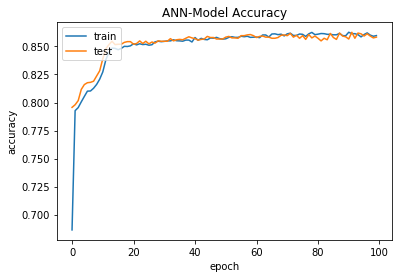

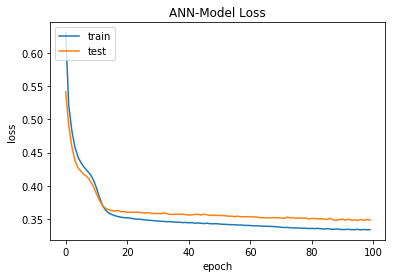

In [37]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('ANN-Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('ANN-Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [38]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 6)                 72        
_________________________________________________________________
dense_3 (Dense)              (None, 6)                 42        
_________________________________________________________________
output (Dense)               (None, 1)                 7         
Total params: 121
Trainable params: 121
Non-trainable params: 0
_________________________________________________________________


### 7. Optimize the model (Optional)


### 8. Predict the results using 0.5 as a threshold (Optional)


In [39]:
y_model_pred = model.predict(X_test)
y_pred = (y_model_pred > 0.5) #to classify each probability into True or False

### 9. Print the Accuracy score and confusion matrix (5 points)

In [40]:
cm = confusion_matrix(y_test, y_pred)
print("ANN Model Confussion Matrix : \n {0}\n".format(cm))
#extracting true_positives, false_positives, true_negatives, false_negatives
TN, FP,FN, TP = cm.ravel()
Result=pd.DataFrame(index=["TrueNegatives","FalsePositives","FalseNegatives","TruePositives","Accuracy", "Recall", "Precision", "F1_Score"])

ANN_ModelResult=[TN,FP,FN,TP,accuracy_score(y_test, y_pred), 
                   recall_score(y_test, y_pred), 
                   precision_score(y_test, y_pred),
                   f1_score(y_test, y_pred)]

Result["ANN_Model_Result"]=ANN_ModelResult

print("ANN Model Result : \n\n {0}\n".format(Result))

ANN Model Confussion Matrix : 
 [[2290  105]
 [ 320  285]]

ANN Model Result : 

                 ANN_Model_Result
TrueNegatives        2290.000000
FalsePositives        105.000000
FalseNegatives        320.000000
TruePositives         285.000000
Accuracy                0.858333
Recall                  0.471074
Precision               0.730769
F1_Score                0.572864



### Final Summary :

1. In the given problem statement and dataset, we have built ANN model using TF and Keras.
2. After EDA process, we have come up with 11 Features and 1 Target (Exited) column.
3. In the given dataset, we have totally 10000 records.
4. Then we split 70:30 for train & test data and done the Normalization.
5. We have initialize the ANN model with 